## This notebook trains an SBERT model on the MRPC Dataset

In [44]:
#Importing required packages
import os
import sys
import time
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sys.path.append(os.path.abspath(".."))

from src.sbert_models import (
    load_sbert_model,
    generate_embeddings,
    concatenate_embeddings
)

from src.classical_models import (
    train_logistic_regression,
    predict
)

from src.evaluate import (
    evaluate_classifier,
    compute_confusion_matrix
)

from src.utils import log_experiment

In [2]:
#Load the processed datasets
train = pd.read_csv(
    "../datasets/processed/classical/mrpc_train.csv"
)

validation = pd.read_csv(
    "../datasets/processed/classical/mrpc_validation.csv"
)

test = pd.read_csv(
    "../datasets/processed/classical/mrpc_test.csv"
)

In [3]:
#Loading sbert
model = load_sbert_model()
print(model)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [4]:
#Generate embeddings
train_emb1 = generate_embeddings(
    model,
    train["sentence1"]
)

train_emb2 = generate_embeddings(
    model,
    train["sentence2"]
)

test_emb1 = generate_embeddings(
    model,
    test["sentence1"]
)

test_emb2 = generate_embeddings(
    model,
    test["sentence2"]
)

validation_emb1 = generate_embeddings(
    model,
    validation["sentence1"]
)

validation_emb2 = generate_embeddings(
    model,
    validation["sentence2"]
)

Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Batches:   0%|          | 0/54 [00:00<?, ?it/s]

Batches:   0%|          | 0/54 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [5]:
#Concatenate
X_train = concatenate_embeddings(
    train_emb1,
    train_emb2
)

X_validation = concatenate_embeddings(
    validation_emb1,
    validation_emb2
)

X_test = concatenate_embeddings(
    test_emb1,
    test_emb2
)

print(X_train.shape)

(3668, 768)


In [6]:
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]

In [33]:
#Training a logistic regression model
start_time = time.perf_counter()

classifier = train_logistic_regression(
    X_train,
    y_train
)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.7938 seconds


In [34]:
#Predictions
start_time = time.perf_counter()

predictions, probabilities = predict(
    classifier,
    X_validation
)

end_time = time.perf_counter()

inference_time = end_time - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.0035 seconds


In [35]:
#Evaluation
metrics = evaluate_classifier(
    y_validation,
    predictions,
    probabilities
)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.6299
Precision: 0.7207
Recall: 0.7491
F1: 0.7346
ROC-AUC: 0.5613


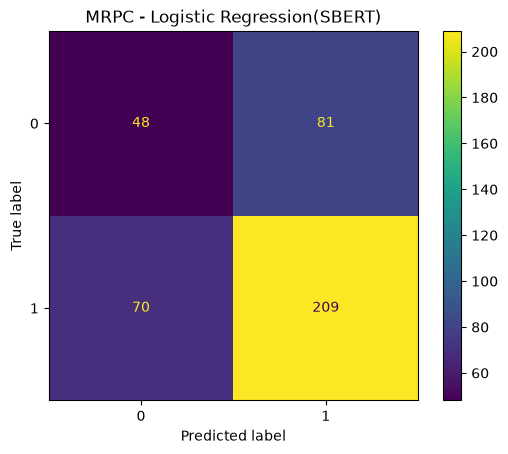

In [36]:
cm = compute_confusion_matrix(
    y_validation,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("MRPC - Logistic Regression(SBERT)")

plt.savefig(
    "../results/plots/mrpc_confusion_matrix(SBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

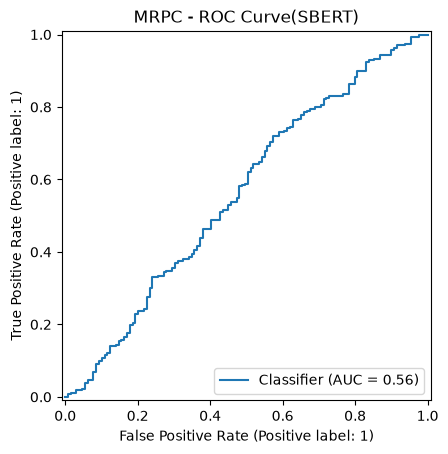

In [37]:
RocCurveDisplay.from_predictions(
    y_validation,
    probabilities
)

plt.title("MRPC - ROC Curve(SBERT)")

plt.savefig(
    "../results/plots/mrpc_roc_curve(SBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
#Saving the results
predictions_df = validation.copy()

predictions_df["prediction"] = predictions
predictions_df["probability"] = probabilities

predictions_df.to_csv(
    "../results/predictions/mrpc_predictions(SBERT).csv",
    index=False
)

predictions_df.head()

,sentence1,sentence2,label,idx,prediction,probability
0,he said the foodservice pie business doesn 't ...,""" the foodservice pie business does not fit ou...",1,9,1,0.926323
1,magnarelli said racicot hated the iraqi regime...,"his wife said he was "" 100 percent behind geor...",0,18,1,0.903369
2,"the dollar was at 116.92 yen against the yen ,...","the dollar was at 116.78 yen jpy = , virtually...",0,25,0,0.451770
3,the afl-cio is waiting until october to decide...,the afl-cio announced wednesday that it will d...,1,32,1,0.945784
4,no dates have been set for the civil or the cr...,no dates have been set for the criminal or civ...,0,33,0,0.352223


In [39]:
#Saving the predictions
metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(
    "../results/metrics/mrpc_logreg_metrics(SBERT).csv",
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.629902,0.72069,0.749104,0.734622,0.561279


In [47]:
#Saving the model
from src.utils import save_model

save_model(
    classifier,
    "../models/sbert/mrpc_classifier.pkl"
)

In [41]:
from datetime import date
from src.utils import log_experiment

experiment = {
    "Experiment ID": "EXP-004",
    "Date": date.today().isoformat(),
    "Phase": "SBERT Baseline",
    "Model": "SBERT + Logistic Regression",
    "Dataset": "MRPC",
    "Train Split": len(train),
    "Validation Split": len(validation),
    "Test Split": len(test),
    "Batch Size": 32,
    "Learning Rate": "N/A",
    "Epochs": "N/A",
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1": metrics["F1"],
    "ROC-AUC": metrics["ROC-AUC"],
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": training_time,
    "Inference Time": inference_time,
    "Notes": "all-MiniLM-L6-v2 (384d), concatenated embeddings",
    "Status": "Completed"
}

log_experiment(
    "../logs/experiments.xlsx",
    experiment
)

In [42]:
from src.reporting import ReportGenerator

report = ReportGenerator()

comparison = report.generate_model_comparison()

comparison

,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time,Inference Time
0,Logistic Regression,MRPC,0.727941,0.723404,0.974910,0.830534,0.675863,0.036566,0.000996
2,Logistic Regression,PAWS,0.556500,0.497691,0.274089,0.353499,0.548097,0.695119,0.009175
1,Logistic Regression,QQP,0.767549,0.722849,0.597850,0.654434,0.836436,3.161926,0.008341
3,SBERT + Logistic Regression,MRPC,0.622029,0.700405,0.754141,0.726280,0.586532,0.378343,0.005225
4,SBERT + Logistic Regression,MRPC,0.629902,0.720690,0.749104,0.734622,0.561279,0.793760,0.003465
